In [12]:
# Inverse modelling of magnetic anomaly over a mid-ocean ridge
# Using L1 norm, total variation, robust estimation and IRLS

# For DTU MSc course Inverse Problems and Machine Learning in Earth and Space Physics

# Starting script setting up problem, and synthetic data

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def G_crust(x_j, x_m, h):
    # Regarding constant pre-factor [not crucial for understanding]
    # -\mu_0/2pi = -2 x10-^7
    # But Magnetization in SI Am^-1, data in nT=10^-9 T
    # So finally correct prefactor is -200 [See Parker, 1994 for details]

    x_m = x_m.reshape(1,-1)
    x_j = x_j.reshape(-1,1)
    g= -200 * ((x_m - x_j)**2 - h**2) /((x_m - x_j)**2 + h**2 )**2

    return g


In [14]:
# Set up 1D grid for locations of model magnetization
delta_x_m=0.1
x_m=np.arange(-25, 25+delta_x_m, delta_x_m)

# define data locations
x_j=np.arange(-15,15+1,1)

# Build design matrix
h=2 # Depth of water (km)
G = G_crust(x_j, x_m, h)*delta_x_m

In [15]:
# Define synthetic model
m = np.zeros((len(x_m),1))
ones = np.ones((51,1))

m[np.arange(250-127,251-77)] = 2*ones
m[np.arange(250-76,251-26)] = -2*ones
m[np.arange(250-25,251+25)] = 2*ones
m[np.arange(250+26,251+76)] = -2*ones
m[np.arange(250+77,251+127)] = 2*ones

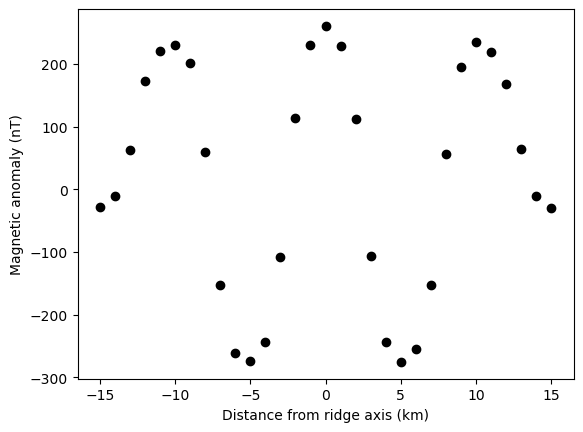

In [ ]:
# Produce synthetic data
d_j=G@m

# Add Gaussian noise of amplitude 8 nT
dn_j=8*np.random.rand(len(d_j),1)
d_j=d_j+dn_j

#Add Outliers
#d_j[12]=300
#d_j[20]=d_j[19]

# Plot data
plt.figure()
plt.plot(x_j,d_j, 'ko')
plt.xlabel('Distance from ridge axis (km)')
plt.ylabel('Magnetic anomaly (nT)')
plt.show()

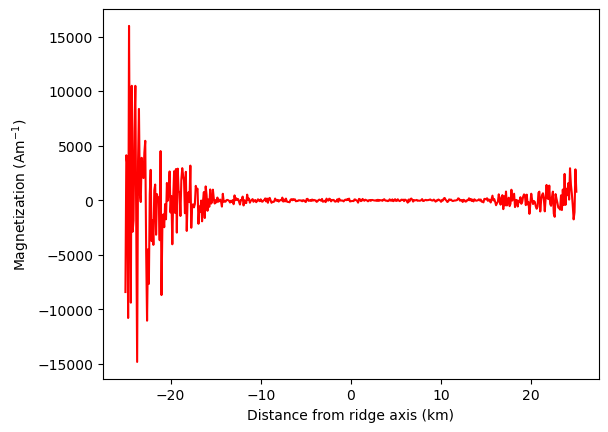

rms misfit: 3.770303666834267e-12


In [17]:
# Simple least squares soln.
m_ls = np.linalg.solve((G.T@G),G.T@d_j) # Direct least sq inversion: v. poor result

# Plot simple least squares soln
plt.figure()
plt.plot(x_m,m_ls,'-r')
plt.xlabel('Distance from ridge axis (km)')
plt.ylabel(r'Magnetization (Am$^{-1}$)')
plt.show()

# Residuals
r_ls=d_j-G@m_ls;
# rms misfit
rms_resid_ls=np.sqrt(r_ls.T@r_ls/len(d_j))
print("rms misfit:", rms_resid_ls[0,0])

rms misfit: 8.11209138586531


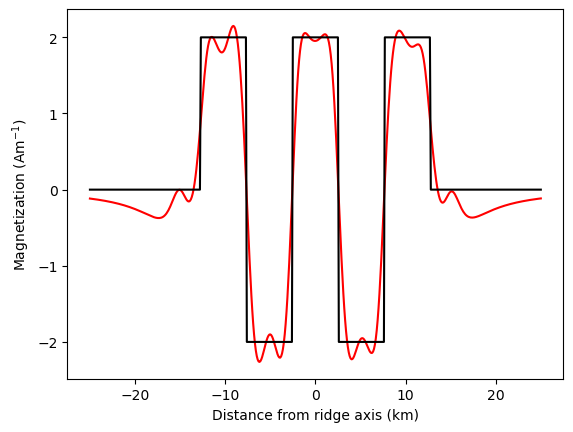

In [ ]:
# L2 norm Tikhonov Regularized solution

alpha_sq=3.95E1  #For discrepancy principle
GTG=G.T@G

# Determine Tikhonov solution
I = np.identity(len(GTG))
m_L2tik = np.linalg.solve((GTG + alpha_sq*I), G.T@d_j)

# Residuals
r_L2tik=d_j-G@m_L2tik
# rms misfit
rms_resid_L2tik=np.sqrt(r_L2tik.T@r_L2tik/len(d_j))
print("rms misfit:",rms_resid_L2tik[0,0])

## Plot regularized solution: much more reasonable
plt.figure()
plt.plot(x_m,m_L2tik,'-r')
plt.plot(x_m, m, 'k')
plt.xlabel('Distance from ridge axis (km)')
plt.ylabel(r'Magnetization (Am$^{-1}$)')
plt.show()

In [19]:
# L1 Regularized solution - this has limitations
# Try alpha_sq_L1=5.8e1 and delta_sq=1e-8

In [ ]:
# Solution for L1 Regularization of model spatial gradients (based on 1st Differences)
# implemented TOGETHER with L1 regularization of model itself (from previous step)

# Find suitable regularization params using discrepancy principle
# Implement L1 norm regularization of spatial gradient first, and find a suitable alpha^2 for this.
# What is unsatisfying about this solution?
# Then go on to also include regularization of the L1 norm of model and fine tune the alpha^2 for this
# Don't spend too long looking for a perfect answer here - is difficult with 2 alpha^2 values

# Try alpha_sq_L1diff = 2e3 and alpha_sq_L1 = 7

In [ ]:
# Solution also using Robust Estimation (Huber weights) from dataset including outliers

#Add Outliers
#d_j[12]=300
#d_j[20]=d_j[19]

# Try alpha_sq_L1=3  and alpha_sq_L1d=3e2 to be useful
